# Step 5 — Polish, Failure Cases and Slide-Ready Summary

**Goal:** Take the raw artefacts from Steps 2–4 and produce the last set of slide-ready figures the presentation still needs — most importantly the **failure cases** (slide 11) and the **combined results dashboard** (slide 14). No new models are trained or run here; this notebook is a rendering layer on top of the cached predictions, CSVs and JSON summaries already on Drive.

## Why a dedicated visualisation notebook

Steps 3 and 4 each produced one representative-case figure and one quantitative figure tied to their own metric. They deliberately skipped failure analysis because the presentation needs the worst cases drawn from the **whole cohort**, not from each notebook individually. Pulling that decision into a separate notebook keeps the Step 3 / Step 4 logic single-purpose and gives us a clean re-runnable home for any further slide polish.

## Design Principle: Idempotent

Every cell is re-runnable. The notebook reads cached files from Drive — it never re-runs inference. If Step 3 or Step 4 has not been completed yet, the corresponding sections fail fast with an actionable message.

## Execution Order

1. Runtime → Change runtime type → **CPU is enough** (no GPU work).
2. Run cells sequentially with **Shift + Enter**.
3. Cell 0 pins the environment and force-restarts the kernel the first time. Re-run that same cell once the runtime comes back up.

## Expected Outputs

- `output/figures/lesion_failure_case.png` — the lowest-Dice csPCa case rendered as a 4-panel slide (slide 11a).
- `output/figures/anatomy_failure_case.png` — the lowest TZ-Dice anatomy case (slide 11b).
- `output/figures/results_summary_card.png` — a one-glance metric card (slide 14 prep).
- `output/figures/results_dashboard.png` — a 2 × 2 dashboard combining the headline metrics and two key case thumbnails.

## 0 — Pin a known-good environment (run this once, then restart the runtime)

Same NumPy 2.0 ↔ MONAI 1.3.2 compatibility constraint as Steps 3–4. We pin `numpy<2` so any MONAI transform we might lazily load behaves correctly. No new pip packages are introduced beyond the Step 4 environment.

If you have already run Step 4 in this Colab runtime, this cell will detect the pinned versions and print a green confirmation immediately. After a kernel reset you will see the runtime restart — re-run this same cell when it comes back up.

In [1]:
import importlib, importlib.util, subprocess, sys, os

REQUIRED = {
    'numpy':      'numpy<2',
    'monai':      'monai[all]==1.3.2',
    'SimpleITK':  'SimpleITK',
    'nibabel':    'nibabel',
    'seaborn':    'seaborn',
}

def _needs_install():
    try:
        import numpy as _np
        if int(_np.__version__.split('.')[0]) >= 2:
            return True, f'numpy {_np.__version__} is too new'
    except ImportError:
        return True, 'numpy missing'
    try:
        import monai as _monai
        if _monai.__version__ != '1.3.2':
            return True, f'monai {_monai.__version__} != 1.3.2'
    except ImportError:
        return True, 'monai missing'
    for mod in ('SimpleITK', 'nibabel', 'seaborn'):
        if importlib.util.find_spec(mod) is None:
            return True, f'{mod} missing'
    return False, 'all pinned versions already installed'

needs, reason = _needs_install()
if needs:
    print(f'Installing pinned environment ({reason}) ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *REQUIRED.values()])
    print('Install complete. Restarting the kernel — re-run this cell after the runtime comes back up.')
    os.kill(os.getpid(), 9)
else:
    import numpy as np, monai
    print(f'Environment OK — numpy {np.__version__}, monai {monai.__version__}.')

Environment OK — numpy 1.26.4, monai 1.3.2.


## 1 — Mount Google Drive and define project paths

Same `PROJECT_ROOT` as every other step. We mount Drive once and resolve every path we need to read from in the rest of the notebook. The two prediction folders (`anatomy_predictions/` and `lesion_predictions/`) and the two metrics folders (`metrics/`) are the entire input of this notebook — we do not touch the raw `images/subset20/` folder except to load T2W / ADC / HBV for visualisation.

In [2]:
from google.colab import drive
import os
from pathlib import Path

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

PROJECT_ROOT       = Path('/content/drive/MyDrive/Prostate_MRI_Project')
INPUT_DIR          = PROJECT_ROOT / 'input'
LABELS_DIR         = INPUT_DIR / 'picai_labels'
DRIVE_SUBSET       = INPUT_DIR / 'images' / 'subset20'
OUTPUT_DIR         = PROJECT_ROOT / 'output'
ANATOMY_PRED_DIR   = OUTPUT_DIR / 'anatomy_predictions'
LESION_PRED_DIR    = OUTPUT_DIR / 'lesion_predictions'
FIGURES_DIR        = OUTPUT_DIR / 'figures'
METRICS_DIR        = OUTPUT_DIR / 'metrics'

ANATOMY_GT_DIR     = LABELS_DIR / 'anatomical_delineations' / 'zonal_pz_tz' / 'AI' / 'Yuan23'
LESION_GT_PRIMARY  = LABELS_DIR / 'csPCa_lesion_delineations' / 'human_expert' / 'resampled'
LESION_GT_FALLBACK = LABELS_DIR / 'csPCa_lesion_delineations' / 'human_expert' / 'Pooch25'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT       : {PROJECT_ROOT}')
print(f'ANATOMY_PRED_DIR   : {ANATOMY_PRED_DIR}')
print(f'LESION_PRED_DIR    : {LESION_PRED_DIR}')
print(f'FIGURES_DIR        : {FIGURES_DIR}')
print(f'METRICS_DIR        : {METRICS_DIR}')

Mounted at /content/drive
PROJECT_ROOT       : /content/drive/MyDrive/Prostate_MRI_Project
ANATOMY_PRED_DIR   : /content/drive/MyDrive/Prostate_MRI_Project/output/anatomy_predictions
LESION_PRED_DIR    : /content/drive/MyDrive/Prostate_MRI_Project/output/lesion_predictions
FIGURES_DIR        : /content/drive/MyDrive/Prostate_MRI_Project/output/figures
METRICS_DIR        : /content/drive/MyDrive/Prostate_MRI_Project/output/metrics


## 2 — Import libraries

Pure visualisation stack: NumPy / pandas for data wrangling, SimpleITK / nibabel for reading the cached masks, matplotlib / seaborn for rendering. No model, no inferer, no `picai_eval` — we only consume the metrics already computed in Step 4.

In [3]:
import json
import numpy as np
import pandas as pd
import SimpleITK as sitk
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

print(f'NumPy      : {np.__version__}')
print(f'pandas     : {pd.__version__}')
print(f'matplotlib : {plt.matplotlib.__version__}')
print(f'seaborn    : {sns.__version__}')

NumPy      : 1.26.4
pandas     : 2.2.2
matplotlib : 3.10.0
seaborn    : 0.13.2


## 3 — Load Step 3 and Step 4 artefacts

Three artefacts feed every later cell:

- `anatomy_dice_scores.csv` (Step 3) — per-case TZ and PZ Dice on the 20-patient subset.
- `lesion_per_case.csv` (Step 4) — per-case Dice, lesion TP/FP/FN, GT-source flag, classification flags.
- `lesion_picai_summary.json` (Step 4) — headline AP, AUROC and PI-CAI ranking score.

If any file is missing the cell fails immediately with an instruction pointing back to the right notebook. This guards against accidentally generating a figure from stale or partial data.

In [4]:
anatomy_csv  = METRICS_DIR / 'anatomy_dice_scores.csv'
lesion_csv   = METRICS_DIR / 'lesion_per_case.csv'
lesion_json  = METRICS_DIR / 'lesion_picai_summary.json'

for p, owner in [(anatomy_csv, 'Step 3'), (lesion_csv, 'Step 4'), (lesion_json, 'Step 4')]:
    assert p.exists(), f'{p} not found. Re-run {owner} first.'

anatomy_df = pd.read_csv(anatomy_csv)
lesion_df  = pd.read_csv(lesion_csv)
with open(lesion_json) as f:
    lesion_summary = json.load(f)

print(f'Anatomy cases  : {len(anatomy_df)}')
print(f'Lesion cases   : {len(lesion_df)}')
print(f'Lesion summary : AP={lesion_summary["AP"]:.3f}, AUROC={lesion_summary["AUROC"]:.3f}, PI-CAI={lesion_summary["PICAI_score"]:.3f}')

Anatomy cases  : 20
Lesion cases   : 20
Lesion summary : AP=0.810, AUROC=1.000, PI-CAI=0.905


## 4 — Lesion failure case figure (slide 11a)

The model's most informative mistake is the case with **Dice = 0 on a positive patient** — both AI and human expert see a lesion, but they place it in completely different locations. This is far more honest than the lowest-Dice positive-positive case where the masks at least partially overlap.

### Case-selection rule

1. Restrict to cases where the human expert annotated a lesion (`gt_has_lesion == 1`).
2. Sort by Dice ascending and pick the lowest one. If multiple cases tie at 0, prefer the one with FP > 0 (an actual misplaced prediction tells a clearer story than a complete miss).

### Panels

1. **T2W** anatomical reference.
2. **ADC** (csPCa appears hypointense).
3. **HBV** (csPCa appears hyperintense — complementary to ADC).
4. **T2W + overlay** — human-expert GT in cyan, AI prediction in magenta. Cells where the two overlap appear lighter.

The chosen slice is the one with the largest **union of GT and AI lesions**, so the figure shows both blobs even when they sit on different axial planes.

Lesion failure case : 10294_1000300
  Dice = 0.000, TP=0, FP=1, FN=1
Saved -> /content/drive/MyDrive/Prostate_MRI_Project/output/figures/lesion_failure_case.png


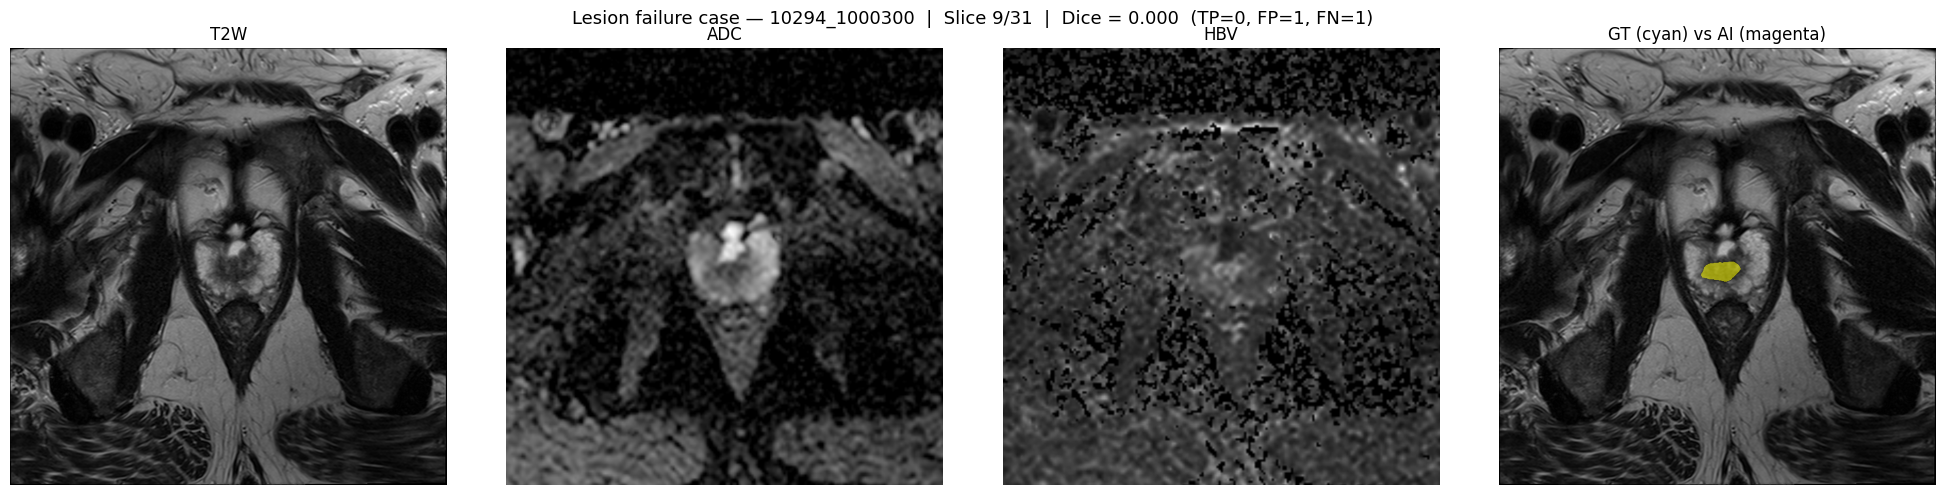

In [5]:
def resample_mask_to_reference(mask_img: sitk.Image, ref_img: sitk.Image) -> sitk.Image:
    r = sitk.ResampleImageFilter()
    r.SetReferenceImage(ref_img)
    r.SetInterpolator(sitk.sitkNearestNeighbor)
    r.SetDefaultPixelValue(0)
    return r.Execute(mask_img)


def resample_image_to_reference(img: sitk.Image, ref_img: sitk.Image) -> sitk.Image:
    r = sitk.ResampleImageFilter()
    r.SetReferenceImage(ref_img)
    r.SetInterpolator(sitk.sitkLinear)
    r.SetDefaultPixelValue(0)
    return r.Execute(img)


positives = lesion_df[lesion_df['gt_has_lesion'] == 1].copy()
positives = positives.sort_values(['dice', 'lesion_fp'], ascending=[True, False])
failure_row = positives.iloc[0]
failure_case = failure_row['case_id']
print(f'Lesion failure case : {failure_case}')
print(f'  Dice = {failure_row["dice"]:.3f}, TP={failure_row["lesion_tp"]}, FP={failure_row["lesion_fp"]}, FN={failure_row["lesion_fn"]}')

patient_id = failure_case.split('_')[0]
t2w_path = DRIVE_SUBSET / patient_id / f'{failure_case}_t2w.mha'
adc_path = DRIVE_SUBSET / patient_id / f'{failure_case}_adc.mha'
hbv_path = DRIVE_SUBSET / patient_id / f'{failure_case}_hbv.mha'
pred_path = LESION_PRED_DIR / f'{failure_case}_lesion_pred.nii.gz'
gt_path = LESION_GT_PRIMARY / f'{failure_case}.nii.gz'
if not gt_path.exists():
    gt_path = LESION_GT_FALLBACK / f'{failure_case}.nii.gz'

gt_img = sitk.ReadImage(str(gt_path))
pred_img = sitk.ReadImage(str(pred_path))
t2w_img = sitk.ReadImage(str(t2w_path))
adc_img = sitk.ReadImage(str(adc_path)) if adc_path.exists() else None
hbv_img = sitk.ReadImage(str(hbv_path)) if hbv_path.exists() else None

t2w_aligned = resample_image_to_reference(t2w_img, gt_img)
pred_aligned = resample_mask_to_reference(pred_img, gt_img)
adc_aligned = resample_image_to_reference(adc_img, gt_img) if adc_img is not None else None
hbv_aligned = resample_image_to_reference(hbv_img, gt_img) if hbv_img is not None else None

t2w_arr  = sitk.GetArrayFromImage(t2w_aligned)
gt_arr   = (sitk.GetArrayFromImage(gt_img).astype(np.uint8)   > 0).astype(np.uint8)
pred_arr = (sitk.GetArrayFromImage(pred_aligned).astype(np.uint8) > 0).astype(np.uint8)
adc_arr  = sitk.GetArrayFromImage(adc_aligned) if adc_aligned is not None else None
hbv_arr  = sitk.GetArrayFromImage(hbv_aligned) if hbv_aligned is not None else None

union_per_slice = ((gt_arr | pred_arr) > 0).sum(axis=(1, 2))
mid = int(np.argmax(union_per_slice)) if union_per_slice.max() > 0 else gt_arr.shape[0] // 2

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(t2w_arr[mid], cmap='gray'); axes[0].set_title('T2W')
if adc_arr is not None:
    axes[1].imshow(adc_arr[mid], cmap='gray'); axes[1].set_title('ADC')
else:
    axes[1].set_axis_off(); axes[1].set_title('ADC missing')
if hbv_arr is not None:
    axes[2].imshow(hbv_arr[mid], cmap='gray'); axes[2].set_title('HBV')
else:
    axes[2].set_axis_off(); axes[2].set_title('HBV missing')
axes[3].imshow(t2w_arr[mid], cmap='gray')
gt_overlay   = np.ma.masked_where(gt_arr[mid]   == 0, gt_arr[mid])
pred_overlay = np.ma.masked_where(pred_arr[mid] == 0, pred_arr[mid])
axes[3].imshow(gt_overlay,   cmap='cool',   alpha=0.55, vmin=0, vmax=1)
axes[3].imshow(pred_overlay, cmap='spring', alpha=0.55, vmin=0, vmax=1)
axes[3].set_title('GT (cyan) vs AI (magenta)')
for ax in axes:
    ax.axis('off')

plt.suptitle(
    f'Lesion failure case — {failure_case}  |  Slice {mid + 1}/{gt_arr.shape[0]}  |  Dice = {failure_row["dice"]:.3f}  '
    f'(TP={failure_row["lesion_tp"]}, FP={failure_row["lesion_fp"]}, FN={failure_row["lesion_fn"]})',
    fontsize=13,
)
plt.tight_layout()
fig_path = FIGURES_DIR / 'lesion_failure_case.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {fig_path}')
plt.show()

## 5 — Anatomy failure case figure (slide 11b)

For the anatomical model we pick the case with the **lowest TZ Dice**. TZ rather than PZ because TZ is the larger and easier zone in prostate158 (reference Dice 0.88) — a poor TZ score is a more striking failure than a poor PZ score (where 0.75 is normal).

The figure is intentionally similar in structure to Step 3's qualitative figure so the audience can read the two slides identically: T2W input, ground-truth zonal labels, and the model's prediction. The slice with the largest predicted prostate area is shown — same selection rule as Step 3.

Anatomy failure case : 10022_1000022
  Dice TZ = 0.000, Dice PZ = 0.888
Saved -> /content/drive/MyDrive/Prostate_MRI_Project/output/figures/anatomy_failure_case.png


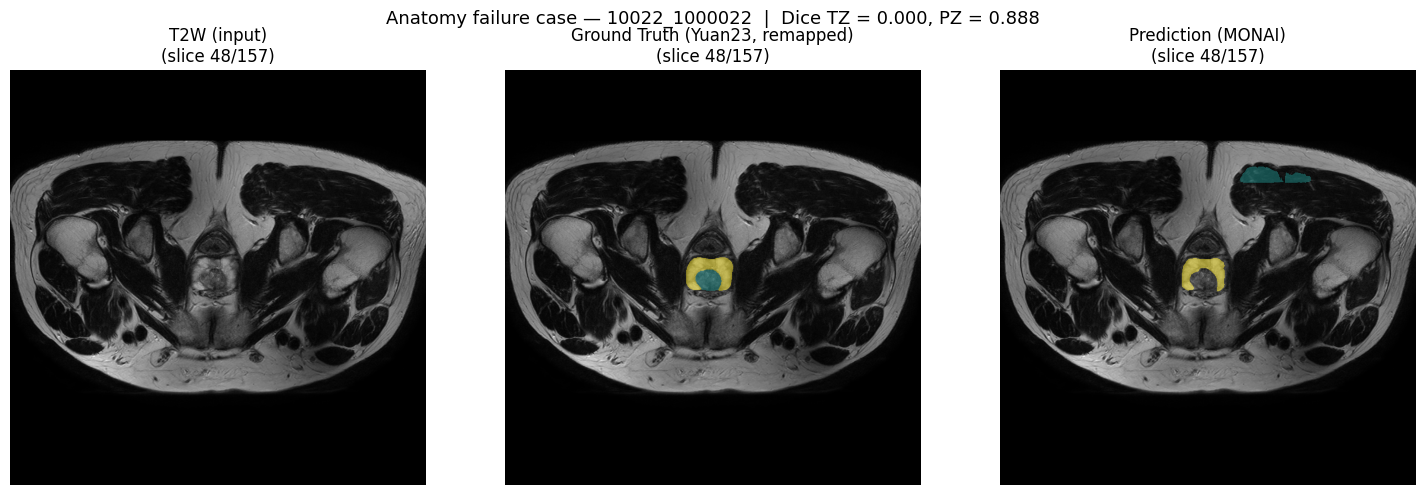

In [6]:
def remap_yuan23_to_monai(gt_arr: np.ndarray) -> np.ndarray:
    """Yuan23 zonal labels use 1=PZ, 2=TZ while the MONAI bundle predicts
    1=TZ, 2=PZ. Swap them so the same color = same anatomy in the overlay."""
    remapped = np.zeros_like(gt_arr)
    remapped[gt_arr == 1] = 2
    remapped[gt_arr == 2] = 1
    return remapped


anatomy_sorted = anatomy_df.sort_values('dice_tz', ascending=True).reset_index(drop=True)
anatomy_failure = anatomy_sorted.iloc[0]
fail_case = anatomy_failure['case_id']
print(f'Anatomy failure case : {fail_case}')
print(f'  Dice TZ = {anatomy_failure["dice_tz"]:.3f}, Dice PZ = {anatomy_failure["dice_pz"]:.3f}')

patient_id = fail_case.split('_')[0]
t2w_path  = DRIVE_SUBSET / patient_id / f'{fail_case}_t2w.mha'
pred_path = ANATOMY_PRED_DIR / f'{fail_case}_zonal_pred.nii.gz'
gt_path   = ANATOMY_GT_DIR / f'{fail_case}.nii.gz'

pred_img = sitk.ReadImage(str(pred_path))
t2w_aligned = resample_image_to_reference(sitk.ReadImage(str(t2w_path)), pred_img)
gt_aligned  = resample_mask_to_reference(sitk.ReadImage(str(gt_path)),  pred_img)

t2w_arr  = sitk.GetArrayFromImage(t2w_aligned)
pred_arr = sitk.GetArrayFromImage(pred_img)
gt_arr   = remap_yuan23_to_monai(sitk.GetArrayFromImage(gt_aligned).astype(np.uint8))

prostate_per_slice = (pred_arr > 0).sum(axis=(1, 2))
mid = int(np.argmax(prostate_per_slice)) if prostate_per_slice.max() > 0 else pred_arr.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
panels = [
    ('T2W (input)',                       None,     None),
    ('Ground Truth (Yuan23, remapped)',   gt_arr,   'viridis'),
    ('Prediction (MONAI)',                pred_arr, 'viridis'),
]
for ax, (title, mask, cmap) in zip(axes, panels):
    ax.imshow(t2w_arr[mid], cmap='gray')
    if mask is not None:
        overlay = np.ma.masked_where(mask[mid] == 0, mask[mid])
        ax.imshow(overlay, cmap=cmap, alpha=0.5, vmin=0, vmax=2)
    ax.set_title(f'{title}\n(slice {mid + 1}/{pred_arr.shape[0]})')
    ax.axis('off')

plt.suptitle(
    f'Anatomy failure case — {fail_case}  |  Dice TZ = {anatomy_failure["dice_tz"]:.3f}, PZ = {anatomy_failure["dice_pz"]:.3f}',
    fontsize=13,
)
plt.tight_layout()
fig_path = FIGURES_DIR / 'anatomy_failure_case.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {fig_path}')
plt.show()

## 6 — Results summary card (slide 14 prep)

A single-image summary that puts every headline number from Steps 3–4 in one place, so slide 14 (conclusion) does not need a busy table. The card has two columns:

- **Anatomy (Step 3)** — mean Dice for the transitional zone and peripheral zone, the reference numbers from prostate158, and the case count.
- **Lesion detection (Step 4)** — the official PI-CAI ranking trio (AP, AUROC, PI-CAI score), case-level sensitivity / specificity / accuracy derived from `lesion_per_case.csv`, the mean voxel Dice over positive cases, and the reference numbers from Bosma et al. 2022.

Rendering uses matplotlib's `text` API with a hand-tuned layout so the card stays readable when shrunk to fit a slide footer; no extra dependencies are introduced.

Saved -> /content/drive/MyDrive/Prostate_MRI_Project/output/figures/results_summary_card.png


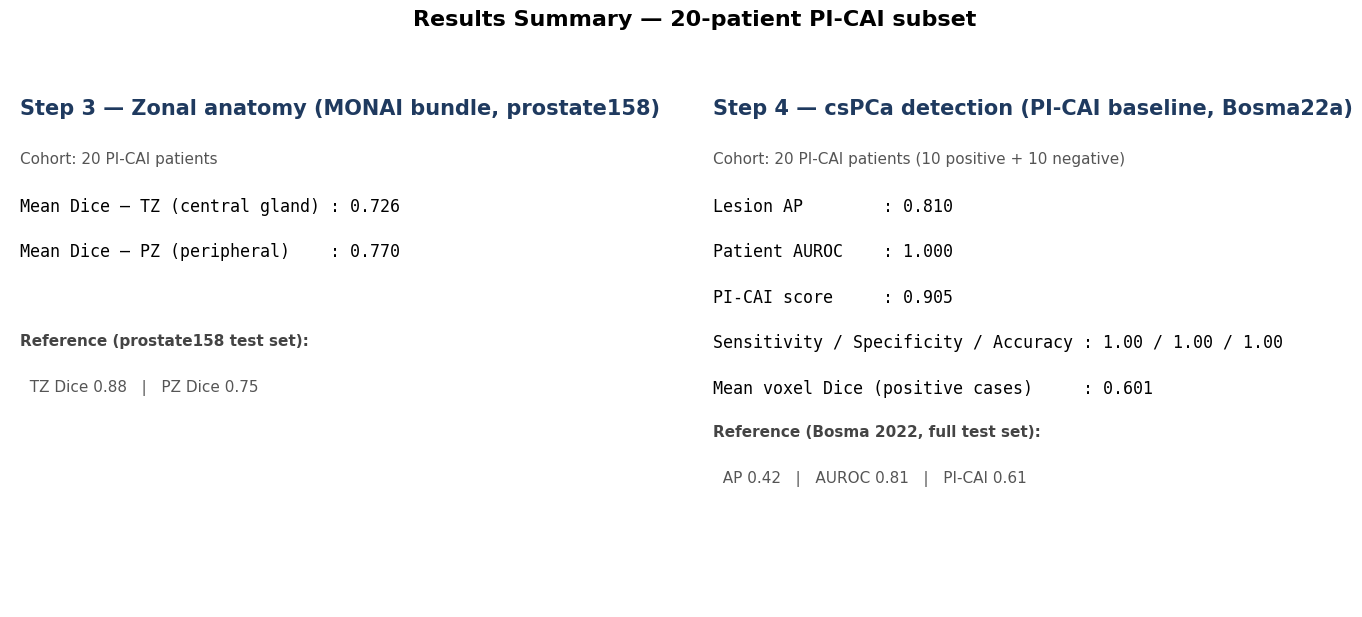

In [7]:
mean_tz = anatomy_df['dice_tz'].mean()
mean_pz = anatomy_df['dice_pz'].mean()

y_true_case = lesion_df['gt_has_lesion'].to_numpy()
y_pred_case = lesion_df['pred_has_lesion'].to_numpy()
tp = int(((y_true_case == 1) & (y_pred_case == 1)).sum())
fp = int(((y_true_case == 0) & (y_pred_case == 1)).sum())
fn = int(((y_true_case == 1) & (y_pred_case == 0)).sum())
tn = int(((y_true_case == 0) & (y_pred_case == 0)).sum())
sens = tp / (tp + fn) if (tp + fn) else float('nan')
spec = tn / (tn + fp) if (tn + fp) else float('nan')
acc  = (tp + tn) / len(y_true_case) if len(y_true_case) else float('nan')
mean_lesion_dice = lesion_df['dice'].dropna().mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax in axes:
    ax.axis('off')

anatomy_lines = [
    ('Step 3 — Zonal anatomy (MONAI bundle, prostate158)', 'header'),
    (f'Cohort: 20 PI-CAI patients',                          'body'),
    (f'Mean Dice — TZ (central gland) : {mean_tz:.3f}',      'metric'),
    (f'Mean Dice — PZ (peripheral)    : {mean_pz:.3f}',      'metric'),
    ('',                                                     'body'),
    ('Reference (prostate158 test set):',                    'subheader'),
    ('  TZ Dice 0.88   |   PZ Dice 0.75',                    'body'),
]
lesion_lines = [
    ('Step 4 — csPCa detection (PI-CAI baseline, Bosma22a)', 'header'),
    (f'Cohort: 20 PI-CAI patients (10 positive + 10 negative)', 'body'),
    (f'Lesion AP        : {lesion_summary["AP"]:.3f}',       'metric'),
    (f'Patient AUROC    : {lesion_summary["AUROC"]:.3f}',    'metric'),
    (f'PI-CAI score     : {lesion_summary["PICAI_score"]:.3f}', 'metric'),
    (f'Sensitivity / Specificity / Accuracy : {sens:.2f} / {spec:.2f} / {acc:.2f}', 'metric'),
    (f'Mean voxel Dice (positive cases)     : {mean_lesion_dice:.3f}', 'metric'),
    ('Reference (Bosma 2022, full test set):',               'subheader'),
    ('  AP 0.42   |   AUROC 0.81   |   PI-CAI 0.61',         'body'),
]

STYLES = {
    'header'    : dict(fontsize=15, fontweight='bold', color='#1f3a5f'),
    'subheader' : dict(fontsize=11, fontweight='bold', color='#444444'),
    'metric'    : dict(fontsize=12, color='#000000', family='monospace'),
    'body'      : dict(fontsize=11, color='#555555'),
}

def draw_block(ax, lines):
    y = 0.95
    for text, style_key in lines:
        ax.text(0.02, y, text, transform=ax.transAxes, va='top', ha='left', **STYLES[style_key])
        y -= 0.10 if style_key == 'header' else 0.085

draw_block(axes[0], anatomy_lines)
draw_block(axes[1], lesion_lines)

plt.suptitle('Results Summary — 20-patient PI-CAI subset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
fig_path = FIGURES_DIR / 'results_summary_card.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {fig_path}')
plt.show()

## 7 — Combined results dashboard (slide 14)

A single 2 × 2 dashboard image that captures the entire study at a glance — suitable as the closing visual on the conclusion slide.

| Panel       | Content                                                                                  |
|-------------|------------------------------------------------------------------------------------------|
| Top-left    | Anatomy TZ/PZ Dice boxplot (re-rendered from `anatomy_dice_scores.csv`).                 |
| Top-right   | Lesion case-level confusion matrix (computed from `lesion_per_case.csv`).               |
| Bottom-left | Best lesion case thumbnail — the highest-Dice positive case, T2W + GT/AI overlay.        |
| Bottom-right| Failure lesion case thumbnail — the case picked in section 4, same overlay style.        |

A bold suptitle carries the headline numbers (PI-CAI score, anatomy mean Dice, case-level accuracy) so a viewer reading the slide footer can see the punchline without parsing the panels.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Saved -> /content/drive/MyDrive/Prostate_MRI_Project/output/figures/results_dashboard.png


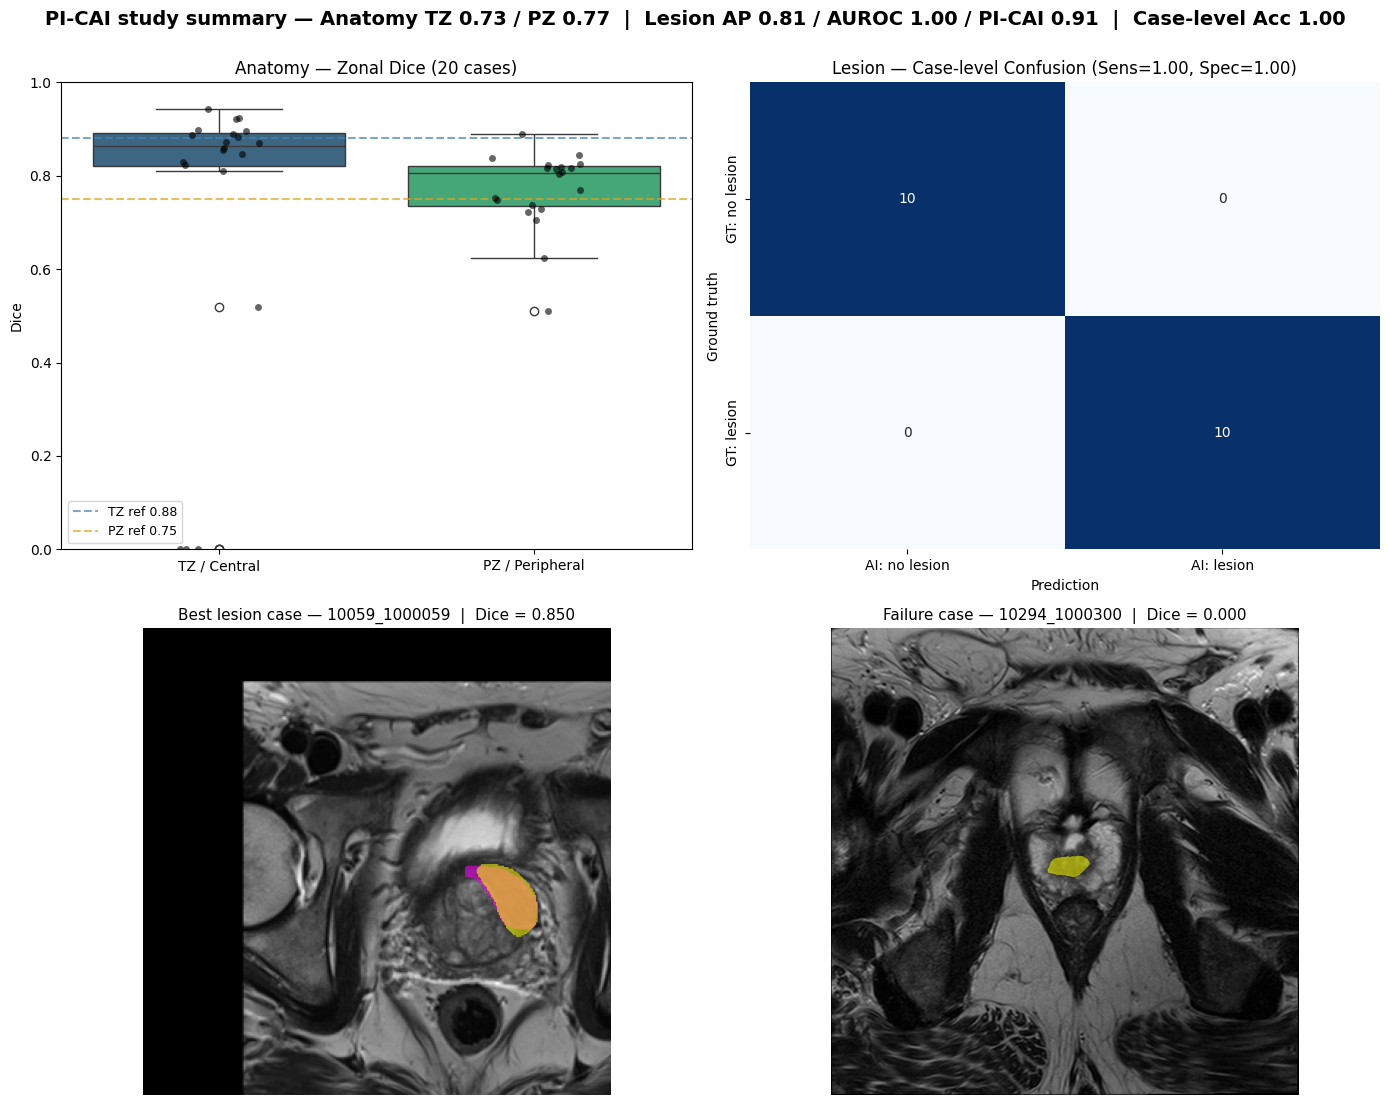

In [8]:
def lesion_overlay_thumbnail(ax, case_id: str, title: str):
    patient_id = case_id.split('_')[0]
    t2w_p = DRIVE_SUBSET / patient_id / f'{case_id}_t2w.mha'
    pred_p = LESION_PRED_DIR / f'{case_id}_lesion_pred.nii.gz'
    gt_p = LESION_GT_PRIMARY / f'{case_id}.nii.gz'
    if not gt_p.exists():
        gt_p = LESION_GT_FALLBACK / f'{case_id}.nii.gz'

    gt_img = sitk.ReadImage(str(gt_p))
    pred_img = sitk.ReadImage(str(pred_p))
    pred_aligned = resample_mask_to_reference(pred_img, gt_img)
    t2w_aligned = resample_image_to_reference(sitk.ReadImage(str(t2w_p)), gt_img)

    t2w_arr  = sitk.GetArrayFromImage(t2w_aligned)
    gt_arr   = (sitk.GetArrayFromImage(gt_img).astype(np.uint8) > 0).astype(np.uint8)
    pred_arr = (sitk.GetArrayFromImage(pred_aligned).astype(np.uint8) > 0).astype(np.uint8)
    union_per_slice = ((gt_arr | pred_arr) > 0).sum(axis=(1, 2))
    slc = int(np.argmax(union_per_slice)) if union_per_slice.max() > 0 else gt_arr.shape[0] // 2

    ax.imshow(t2w_arr[slc], cmap='gray')
    ax.imshow(np.ma.masked_where(gt_arr[slc]   == 0, gt_arr[slc]),   cmap='cool',   alpha=0.55, vmin=0, vmax=1)
    ax.imshow(np.ma.masked_where(pred_arr[slc] == 0, pred_arr[slc]), cmap='spring', alpha=0.55, vmin=0, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.axis('off')


best_row = lesion_df[lesion_df['gt_has_lesion'] == 1].sort_values('dice', ascending=False).iloc[0]
fail_row = positives.iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

long_df = anatomy_df.melt(id_vars='case_id', value_vars=['dice_tz', 'dice_pz'],
                          var_name='zone', value_name='dice')
long_df['zone'] = long_df['zone'].map({'dice_tz': 'TZ / Central', 'dice_pz': 'PZ / Peripheral'})
sns.boxplot(data=long_df, x='zone', y='dice', ax=axes[0,0], palette='viridis')
sns.stripplot(data=long_df, x='zone', y='dice', ax=axes[0,0], color='black', alpha=0.6, jitter=0.15)
axes[0,0].axhline(0.88, ls='--', color='steelblue', alpha=0.7, label='TZ ref 0.88')
axes[0,0].axhline(0.75, ls='--', color='goldenrod', alpha=0.7, label='PZ ref 0.75')
axes[0,0].set_ylim(0, 1)
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Dice')
axes[0,0].set_title('Anatomy — Zonal Dice (20 cases)')
axes[0,0].legend(loc='lower left', fontsize=9)

cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['AI: no lesion', 'AI: lesion'],
            yticklabels=['GT: no lesion', 'GT: lesion'],
            ax=axes[0,1])
axes[0,1].set_title(f'Lesion — Case-level Confusion (Sens={sens:.2f}, Spec={spec:.2f})')
axes[0,1].set_xlabel('Prediction')
axes[0,1].set_ylabel('Ground truth')

lesion_overlay_thumbnail(
    axes[1,0],
    best_row['case_id'],
    f'Best lesion case — {best_row["case_id"]}  |  Dice = {best_row["dice"]:.3f}',
)
lesion_overlay_thumbnail(
    axes[1,1],
    fail_row['case_id'],
    f'Failure case — {fail_row["case_id"]}  |  Dice = {fail_row["dice"]:.3f}',
)

plt.suptitle(
    f'PI-CAI study summary — Anatomy TZ {mean_tz:.2f} / PZ {mean_pz:.2f}  |  '
    f'Lesion AP {lesion_summary["AP"]:.2f} / AUROC {lesion_summary["AUROC"]:.2f} / '
    f'PI-CAI {lesion_summary["PICAI_score"]:.2f}  |  Case-level Acc {acc:.2f}',
    fontsize=14, fontweight='bold', y=1.00,
)
plt.tight_layout()
fig_path = FIGURES_DIR / 'results_dashboard.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Saved -> {fig_path}')
plt.show()

---

## Step 5 Complete

**Produced:**
- `output/figures/lesion_failure_case.png` — lowest-Dice positive csPCa case, 4-panel (slide 11a).
- `output/figures/anatomy_failure_case.png` — lowest TZ-Dice anatomy case, 3-panel (slide 11b).
- `output/figures/results_summary_card.png` — single-image headline metric card (slide 14 prep).
- `output/figures/results_dashboard.png` — 2 × 2 dashboard combining boxplot, confusion matrix and two case thumbnails (slide 14).

**End of the code pipeline.** All four notebooks (Steps 2 → 5) can be re-run in order from a cold Colab runtime and will reproduce every artefact this presentation needs. The next phase is non-code: assembling the slide deck (`python-pptx` or PowerPoint by hand), writing speaker notes, and rehearsing.

---

### If the kernel resets or Colab disconnects

This notebook only reads from Drive — there are no expensive operations to cache. Just re-run from the top.